In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, NotRequired
from pydantic import BaseModel, Field
import operator

/Users/vikrmaditya/Downloads/Code/LangGraph/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

model = ChatGroq(
    model= 'moonshotai/kimi-k2-instruct-0905',
    temperature= 0
)

In [3]:
class EvaluationSchema(BaseModel):
    
    feedback: str = Field(description='Detailed Feedback for the essay')
    score: int = Field(description='Score out of 10', gt=0, le=10)

In [4]:
structured_model = model.with_structured_output(EvaluationSchema)

In [5]:
essay = """

    India in the Age of AI: Opportunity, Responsibility, and Transformation
    The rapid ascent of Artificial Intelligence (AI) has positioned India at a critical technological crossroads. As the nation strives to become a global economic powerhouse, AI is emerging not just as a tool for automation but as a fundamental pillar of national development.

    Building the Foundation The journey begins with the intellectual capital required to build cutting-edge AI systems. Premier institutions like the IITs, IIITs, and IISc have already begun fostering advanced research, while private sector leaders such as TCS, Infosys, and Wipro are integrating AI into their global service suites. Recognizing this potential, the government launched the National AI Strategy (AI for All) in 2020. This roadmap focuses on inclusive growth, aiming to leverage AI in critical sectors like healthcare, agriculture, education, and smart mobility.

    Bridging the Socio-Economic Gap One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasting, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in underserved rural areas. Furthermore, educational platforms are increasingly using AI to personalize learning paths, while smart governance tools help improve public service delivery and fraud detection.

    The Roadblocks to AI-led Growth However, the path to such growth is riddled with challenges, chief among them being the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. Furthermore, the risk of job displacement due to automation looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could potentially exacerbate existing socio-economic inequalities.

    Ethics and Governance Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still in the process of shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems risk being marred by misuse or algorithmic bias.

    The Way Forward To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain a strategic advantage and ensure interoperability in global systems.

    Conclusion India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. However, this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development. Ultimately, India’s story in the age of AI is one in the making—a narrative that will determine not just the nation's technological trajectory, but also its future as an inclusive, equitable, and innovation-driven society.

    """

In [6]:
# prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'

# answer = structured_model.invoke(prompt)

# answer

In [7]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: NotRequired[str]
    analysis_feedback: NotRequired[str]
    clarity_feedback: NotRequired[str]
    overall_feedback: NotRequired[str]
    individual_score: NotRequired[Annotated[list[int], operator.add]]
    avg_score: NotRequired[float]

In [8]:
def eval_lang(state: UPSCState) -> UPSCState:

    prompt = f"""System: You are an expert UPSC evaluator.
Task: Evaluate the language quality of the provided essay.

Constraints:
1. Feedback must be objective and cite specific examples.
2. Score must be a single integer between 1 and 10.

Essay:
{state['essay']}"""
    lang_evaluation = structured_model.invoke(prompt)
    return {'language_feedback': lang_evaluation.feedback, 'individual_score': [lang_evaluation.score]}

In [9]:
def eval_analysis(state: UPSCState) -> UPSCState:

    prompt = f"""System: You are an expert UPSC evaluator.
Task: Evaluate the depth of analysis of the provided essay.

Constraints:
1. Feedback must be objective and cite specific examples.
2. Score must be a single integer between 1 and 10.

Essay:
{state['essay']}"""
    analysis_evaluation = structured_model.invoke(prompt)
    return {'analysis_feedback': analysis_evaluation.feedback, 'individual_score': [analysis_evaluation.score]}

In [10]:
def eval_thought(state: UPSCState) -> UPSCState:

    prompt = f"""System: You are an expert UPSC evaluator.
Task: Evaluate the clarity of thought and logical flow of the provided essay.

Constraints:
1. Feedback must be objective and cite specific examples.
2. Score must be a single integer between 1 and 10.

Essay:
{state['essay']}"""
    thought_evaluation = structured_model.invoke(prompt)
    return {'clarity_feedback': thought_evaluation.feedback, 'individual_score': [thought_evaluation.score]}

In [11]:
def eval_final(state: UPSCState) -> UPSCState:

    prompt = f"""
        Based on the following feedbacks, create a summarized feedback:

        Language feedback - {state["language_feedback"]}

        In-depth analysis feedback - {state["analysis_feedback"]}

        Clarity of thought feedback - {state["clarity_feedback"]}
    """

    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_score']) / len(state['individual_score']) if state['individual_score'] else 0.0

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

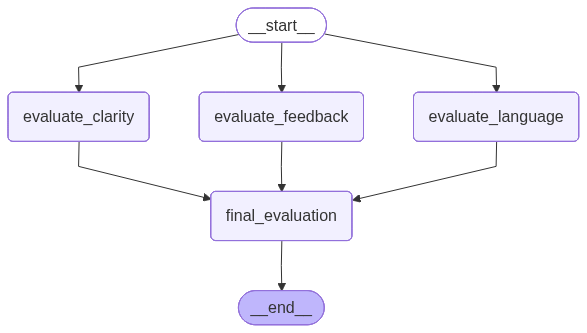

In [12]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', eval_lang)
graph.add_node('evaluate_feedback', eval_analysis)
graph.add_node('evaluate_clarity', eval_thought)
graph.add_node('final_evaluation', eval_final)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_feedback')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_feedback', 'final_evaluation')
graph.add_edge('evaluate_clarity', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

workflow

In [13]:
initial_state = {
    'essay': essay
}

final_state = workflow.invoke(initial_state)

final_state

{'essay': "\n\n    India in the Age of AI: Opportunity, Responsibility, and Transformation\n    The rapid ascent of Artificial Intelligence (AI) has positioned India at a critical technological crossroads. As the nation strives to become a global economic powerhouse, AI is emerging not just as a tool for automation but as a fundamental pillar of national development.\n\n    Building the Foundation The journey begins with the intellectual capital required to build cutting-edge AI systems. Premier institutions like the IITs, IIITs, and IISc have already begun fostering advanced research, while private sector leaders such as TCS, Infosys, and Wipro are integrating AI into their global service suites. Recognizing this potential, the government launched the National AI Strategy (AI for All) in 2020. This roadmap focuses on inclusive growth, aiming to leverage AI in critical sectors like healthcare, agriculture, education, and smart mobility.\n\n    Bridging the Socio-Economic Gap One of the